In [1]:
import importlib
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import copy
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision 
from torchvision import transforms

import defHelp
importlib.reload(defHelp)
from defHelp import plot_history, fit, EarlyStopping, accuracy_from_logits, evaluate, train_one_epoch 

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
print("torchvision:", torchvision.__version__)
print(f"device: {device}")

torch: 2.10.0+cpu
cuda: None
torchvision: 0.25.0+cpu
device: cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_full = torchvision.datasets.EMNIST(split="balanced", root="./data", train=True, download=False, transform=transform)
test_ds = torchvision.datasets.EMNIST(split="balanced", root="./data", train=False, download=False, transform=transform)

class_names = train_full.classes
print(f"classes: {train_full.classes}, ({len(class_names)})")
print(f"train size: {len(train_full)}")
print(f"test size: {len(test_ds)}")


classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'], (47)
train size: 112800
test size: 18800


In [3]:
BATCH_SIZE = 128
NUM_WORKERS = 6
gen = torch.Generator().manual_seed(42)

train_ds, val_ds = random_split(train_full, [int(len(train_full) * 0.8), len(train_full) - int(len(train_full) * 0.8)], generator=gen)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory="False")
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory="False")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory="False")

x_batch, y_batch = next(iter(train_loader))
print(f"x_batch: {x_batch.shape}, {x_batch.dtype}")
print(f"y_batch: {y_batch.shape}, {y_batch.dtype}")


d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x_batch: torch.Size([128, 1, 28, 28]), torch.float32
y_batch: torch.Size([128]), torch.int64


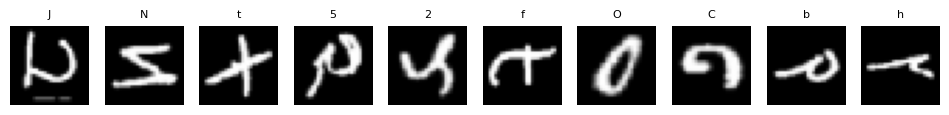

In [24]:
def show_images(loader, n=10):
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]
    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.1307 + 0.3081
        plt.imshow(img, cmap="gray")
        plt.title(train_full.classes[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)
    

In [4]:
class MLP(nn.Module):
    def __init__(
            self, 
            input_dim=28*28,
            hidden_dims=(512, 256, 128),
            num_classes=47,
            activation="relu",
            dropout_p=0.0,
            use_batchnorm=False):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/20 | train loss=0.9901, acc=0.7015 | val loss=0.6346, acc=0.7956
epoch 02/20 | train loss=0.5444, acc=0.8164 | val loss=0.5258, acc=0.8248
epoch 03/20 | train loss=0.4494, acc=0.8426 | val loss=0.4977, acc=0.8315
epoch 04/20 | train loss=0.3935, acc=0.8586 | val loss=0.4791, acc=0.8405
epoch 05/20 | train loss=0.3560, acc=0.8693 | val loss=0.4591, acc=0.8472
epoch 06/20 | train loss=0.3239, acc=0.8781 | val loss=0.4802, acc=0.8431
epoch 07/20 | train loss=0.2967, acc=0.8864 | val loss=0.4984, acc=0.8436
epoch 08/20 | train loss=0.2774, acc=0.8910 | val loss=0.5036, acc=0.8404
epoch 09/20 | train loss=0.2609, acc=0.8966 | val loss=0.5195, acc=0.8376
epoch 10/20 | train loss=0.2412, acc=0.9030 | val loss=0.5286, acc=0.8476
epoch 11/20 | train loss=0.2301, acc=0.9072 | val loss=0.5394, acc=0.8448
epoch 12/20 | train loss=0.2220, acc=0.9098 | val loss=0.5655, acc=0.8431
epoch 13/20 | train loss=0.2082, acc=0.9158 | val loss=0.5843, acc=0.8427
epoch 14/20 | train loss=0.2020, acc=0

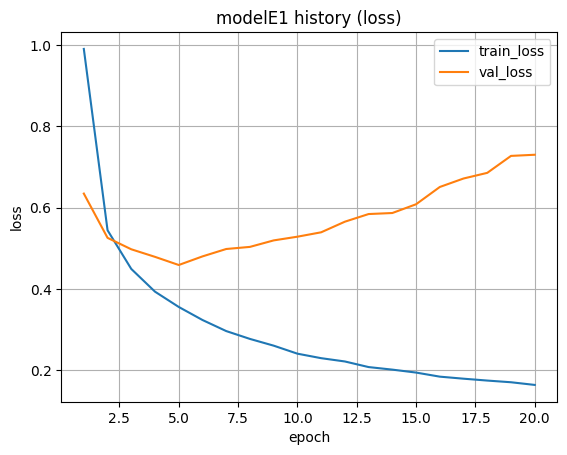

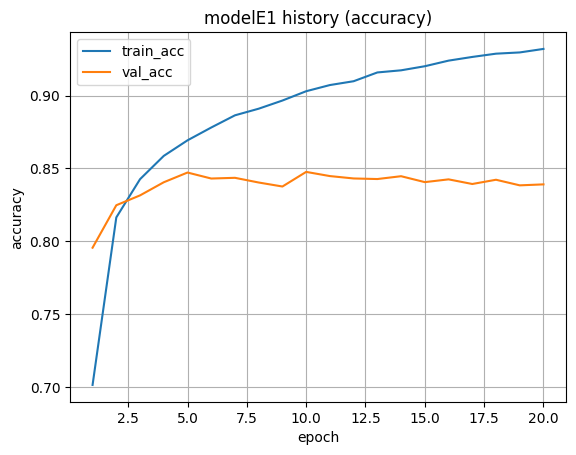

In [83]:
modelE1 = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelE1.parameters(), lr=1e-3)

history_E1 = fit(modelE1, train_loader, val_loader, optimizer, criterion, device)

plot_history(history_E1, "modelE1 history")

In [90]:
runs = pd.read_csv("./artifacts/runs.csv")

new_row = {
    "experiment_id": "E1",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": False},
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 20,
    "best_val_accuracy": max(history_E1["val_acc"]),
    "best_val_loss": min(history_E1["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)


In [ ]:
best_acc = 0.0
history_best_modelE2 = None
best_modelE2 = None

for p in (0.2, 0.3, 0.4, 0.5):
    modelE2 = MLP(dropout_p=p).to(device)
    optimizer = optim.Adam(modelE2.parameters(), lr=1e-3)
    
    print(f"{p}:")
    history_E2 = fit(modelE2, train_loader, val_loader, optimizer, criterion, device)
    if max(history_E2["val_acc"]) > best_acc:
        history_best_modelE2 = history_E2
        best_modelE2 = copy.deepcopy(modelE2)
        best_acc = max(history_E2["val_acc"])
     

0.2:


d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/20 | train loss=1.1964, acc=0.6423 | val loss=0.6443, acc=0.7925
epoch 02/20 | train loss=0.6983, acc=0.7738 | val loss=0.5338, acc=0.8218
epoch 03/20 | train loss=0.5943, acc=0.8019 | val loss=0.5099, acc=0.8279
epoch 04/20 | train loss=0.5443, acc=0.8140 | val loss=0.4840, acc=0.8374
epoch 05/20 | train loss=0.5110, acc=0.8245 | val loss=0.4698, acc=0.8394
epoch 06/20 | train loss=0.4865, acc=0.8315 | val loss=0.4635, acc=0.8448
epoch 07/20 | train loss=0.4634, acc=0.8386 | val loss=0.4515, acc=0.8487
epoch 08/20 | train loss=0.4474, acc=0.8428 | val loss=0.4434, acc=0.8504
epoch 09/20 | train loss=0.4354, acc=0.8456 | val loss=0.4456, acc=0.8499
epoch 10/20 | train loss=0.4178, acc=0.8493 | val loss=0.4594, acc=0.8475
epoch 11/20 | train loss=0.4097, acc=0.8521 | val loss=0.4430, acc=0.8511
epoch 12/20 | train loss=0.3988, acc=0.8556 | val loss=0.4430, acc=0.8551
epoch 13/20 | train loss=0.3931, acc=0.8572 | val loss=0.4443, acc=0.8537
epoch 14/20 | train loss=0.3850, acc=0

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.3, inplace=False)
    (10): Linear(in_features=128, out_features=47, bias=True)
  )
)


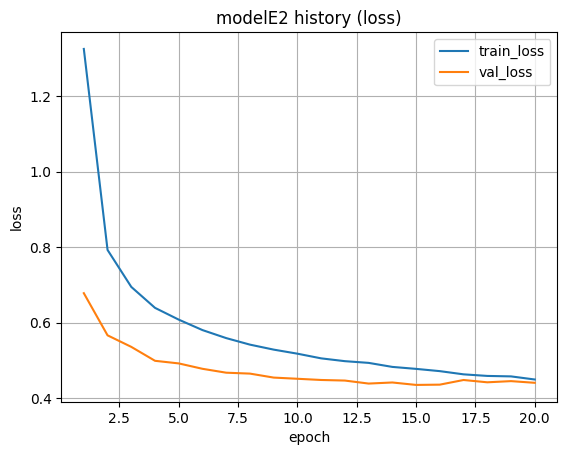

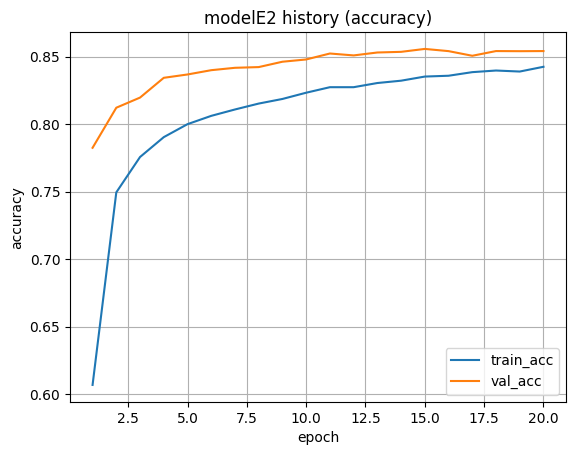

In [89]:
print(best_modelE2)
plot_history(history_best_modelE2, "modelE2 history")

In [91]:
new_row = {
    "experiment_id": "E2",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.3, 
                      "batchnorm": False},
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 20,
    "best_val_accuracy": max(history_best_modelE2["val_acc"]),
    "best_val_loss": min(history_best_modelE2["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/20 | train loss=0.9027, acc=0.7482 | val loss=0.5489, acc=0.8197
epoch 02/20 | train loss=0.4876, acc=0.8343 | val loss=0.4682, acc=0.8404
epoch 03/20 | train loss=0.4125, acc=0.8548 | val loss=0.4619, acc=0.8401
epoch 04/20 | train loss=0.3659, acc=0.8673 | val loss=0.4381, acc=0.8504
epoch 05/20 | train loss=0.3318, acc=0.8774 | val loss=0.4378, acc=0.8524
epoch 06/20 | train loss=0.3019, acc=0.8855 | val loss=0.4253, acc=0.8589
epoch 07/20 | train loss=0.2772, acc=0.8934 | val loss=0.4351, acc=0.8558
epoch 08/20 | train loss=0.2598, acc=0.8996 | val loss=0.4404, acc=0.8525
epoch 09/20 | train loss=0.2457, acc=0.9034 | val loss=0.4609, acc=0.8532
epoch 10/20 | train loss=0.2290, acc=0.9091 | val loss=0.4516, acc=0.8586
epoch 11/20 | train loss=0.2146, acc=0.9136 | val loss=0.4767, acc=0.8507
epoch 12/20 | train loss=0.2079, acc=0.9149 | val loss=0.4723, acc=0.8527
epoch 13/20 | train loss=0.1952, acc=0.9206 | val loss=0.4741, acc=0.8548
epoch 14/20 | train loss=0.1845, acc=0

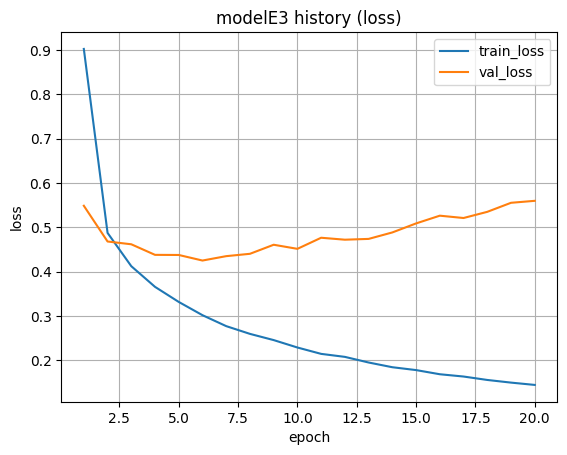

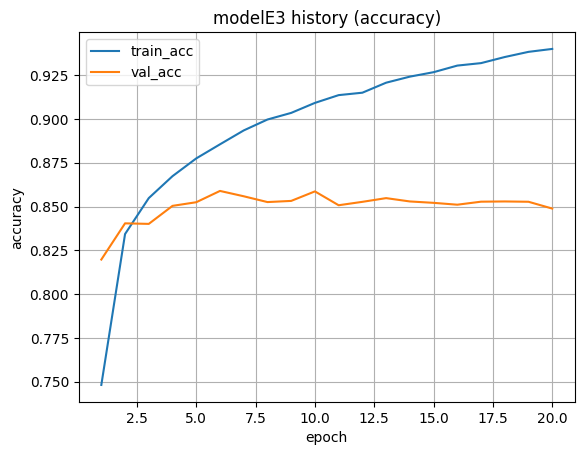

In [85]:
modelE3 = MLP(use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelE3.parameters(), lr=1e-3)

history_E3 = fit(modelE3, train_loader, val_loader, optimizer, criterion, device)

plot_history(history_E3, "modelE3 history")

In [92]:
new_row = {
    "experiment_id": "E3",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": True},
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 20,
    "best_val_accuracy": max(history_E3["val_acc"]),
    "best_val_loss": min(history_E3["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/100 | train loss=0.8952, acc=0.7477 | val loss=0.5567, acc=0.8159
epoch 02/100 | train loss=0.4886, acc=0.8335 | val loss=0.4768, acc=0.8370
epoch 03/100 | train loss=0.4106, acc=0.8547 | val loss=0.4452, acc=0.8478
epoch 04/100 | train loss=0.3629, acc=0.8690 | val loss=0.4372, acc=0.8496
epoch 05/100 | train loss=0.3287, acc=0.8777 | val loss=0.4458, acc=0.8509
epoch 06/100 | train loss=0.3035, acc=0.8844 | val loss=0.4420, acc=0.8497
epoch 07/100 | train loss=0.2828, acc=0.8905 | val loss=0.4245, acc=0.8564
epoch 08/100 | train loss=0.2601, acc=0.8981 | val loss=0.4488, acc=0.8509
epoch 09/100 | train loss=0.2461, acc=0.9021 | val loss=0.4427, acc=0.8577
epoch 10/100 | train loss=0.2279, acc=0.9086 | val loss=0.4623, acc=0.8518
epoch 11/100 | train loss=0.2181, acc=0.9114 | val loss=0.4598, acc=0.8563
epoch 12/100 | train loss=0.2083, acc=0.9145 | val loss=0.4661, acc=0.8543
epoch 13/100 | train loss=0.1962, acc=0.9192 | val loss=0.4839, acc=0.8513
epoch 14/100 | train loss

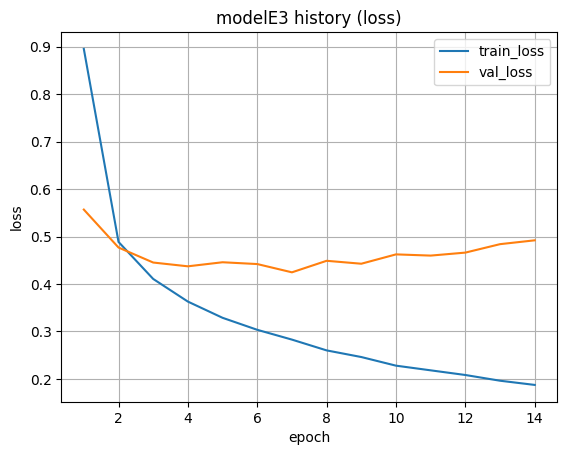

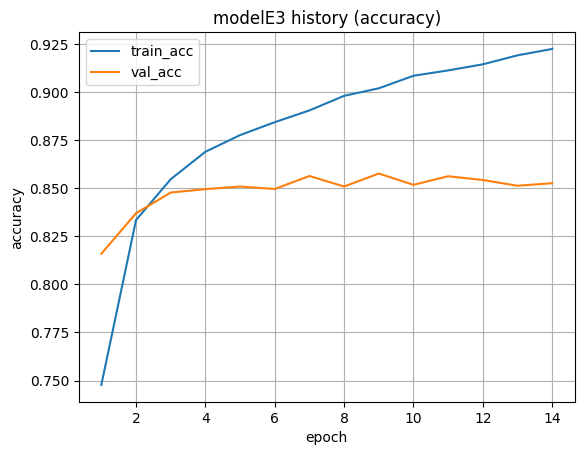

In [ ]:
modelE4 = MLP(use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelE4.parameters(), lr=1e-3)

history_E4 = fit(modelE4, train_loader, val_loader, optimizer, criterion, device, early_stopping=EarlyStopping(patience=5), epochs=100)


MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=47, bias=True)
  )
)


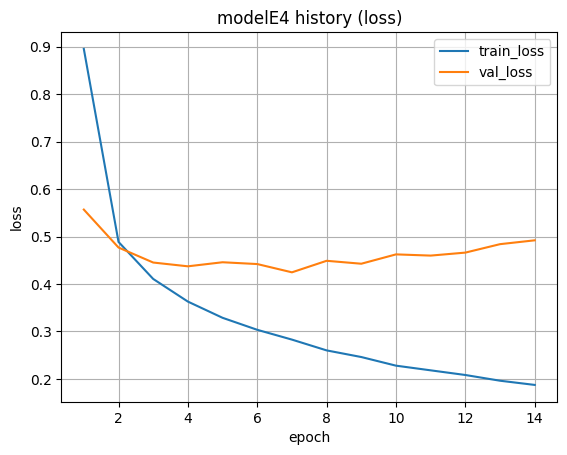

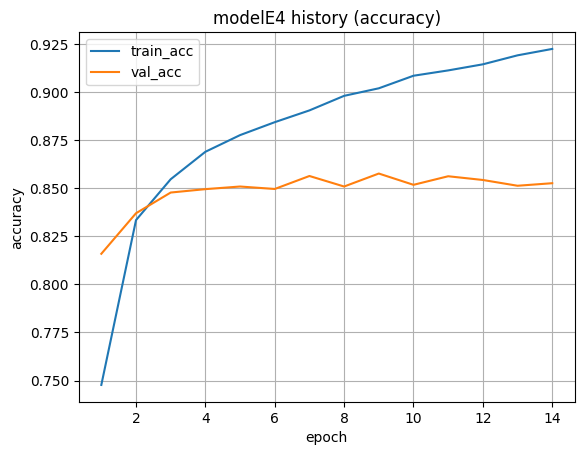

In [99]:
print(modelE4)
plot_history(history_E4, "modelE4 history")

In [ ]:
new_row = {
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": True},
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 14,
    "best_val_accuracy": max(history_E4["val_acc"]),
    "best_val_loss": min(history_E4["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

torch.save(modelE4.state_dict(), "./artifacts/best_model.pt")

config_best_model = {
    "dataset": "EMNIST",
    "seed": 42,

    "architecture": {
        "type": "MLP",
        "input_dim": 28*28,
        "hidden_dims": (512, 256, 128),
        "activation": "ReLU",
        "dropout": 0.0,
        "batchnorm": True,
        "num_classes": 47
    },

    "training": {
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0,
        "epochs": 14,
        "batch_size": 128
    }
}

with open("./artifacts/best_config.json", "w") as f:
    json.dump(config_best_model, f, indent=4)

NameError: name 'modelE4' is not defined

In [9]:
best_model = MLP(use_batchnorm=True).to(device)
state_dict = torch.load("./artifacts/best_model.pt", map_location="cpu")
best_model.load_state_dict(state_dict)
evaluate(best_model, test_loader, nn.CrossEntropyLoss(), device)

d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


(0.4597330298148045, 0.8539540816326531)

d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/8 | train loss=1.6729, acc=0.5194 | val loss=1.2023, acc=0.6333
epoch 02/8 | train loss=1.0173, acc=0.6910 | val loss=0.9395, acc=0.7158
epoch 03/8 | train loss=0.8978, acc=0.7259 | val loss=0.8144, acc=0.7540
epoch 04/8 | train loss=0.8128, acc=0.7486 | val loss=0.8548, acc=0.7472
epoch 05/8 | train loss=0.7829, acc=0.7577 | val loss=0.9393, acc=0.7336
epoch 06/8 | train loss=0.7551, acc=0.7672 | val loss=0.7539, acc=0.7603
epoch 07/8 | train loss=0.7356, acc=0.7715 | val loss=0.7455, acc=0.7780
epoch 08/8 | train loss=0.7059, acc=0.7799 | val loss=0.7296, acc=0.7881


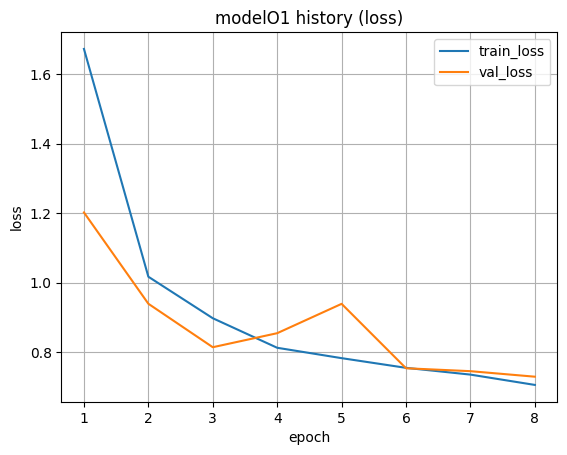

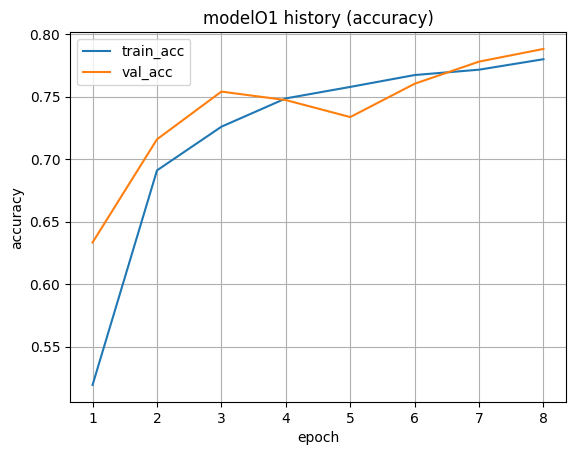

In [9]:
modelO1 = MLP(use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelO1.parameters(), lr=0.3)

history_O1 = fit(modelO1, train_loader, val_loader, optimizer, criterion, device, epochs=8)
plot_history(history_O1, "modelO1 history")

In [ ]:
new_row = {
    "experiment_id": "O1",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": True},
    "optimizer": "Adam",
    "lr": 0.3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 8,
    "best_val_accuracy": max(history_O1["val_acc"]),
    "best_val_loss": min(history_O1["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/8 | train loss=3.8537, acc=0.0402 | val loss=3.7703, acc=0.0601
epoch 02/8 | train loss=3.6897, acc=0.0865 | val loss=3.6182, acc=0.1105
epoch 03/8 | train loss=3.5483, acc=0.1420 | val loss=3.4868, acc=0.1713
epoch 04/8 | train loss=3.4268, acc=0.2000 | val loss=3.3721, acc=0.2294
epoch 05/8 | train loss=3.3213, acc=0.2548 | val loss=3.2734, acc=0.2823
epoch 06/8 | train loss=3.2296, acc=0.3008 | val loss=3.1849, acc=0.3251
epoch 07/8 | train loss=3.1469, acc=0.3413 | val loss=3.1085, acc=0.3598
epoch 08/8 | train loss=3.0732, acc=0.3731 | val loss=3.0372, acc=0.3892


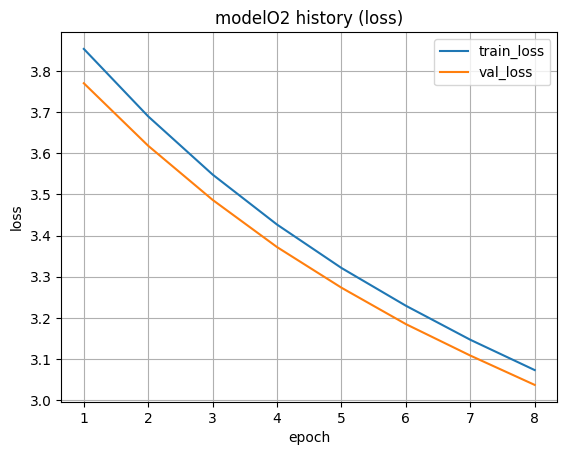

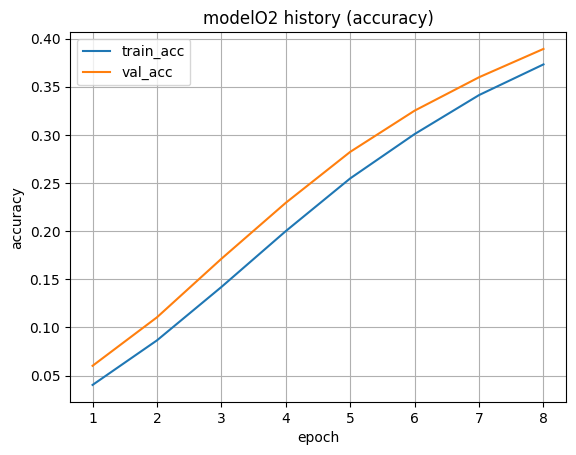

In [11]:
modelO2 = MLP(use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelO2.parameters(), lr=1e-6)

history_O2 = fit(modelO2, train_loader, val_loader, optimizer, criterion, device, epochs=8)
plot_history(history_O2, "modelO2 history")

In [17]:
new_row = {
    "experiment_id": "O2",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": True},
    "optimizer": "Adam",
    "lr": 1e-6,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": 8,
    "best_val_accuracy": max(history_O2["val_acc"]),
    "best_val_loss": min(history_O2["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

C:\Users\user\AppData\Local\Temp\ipykernel_16528\738498572.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


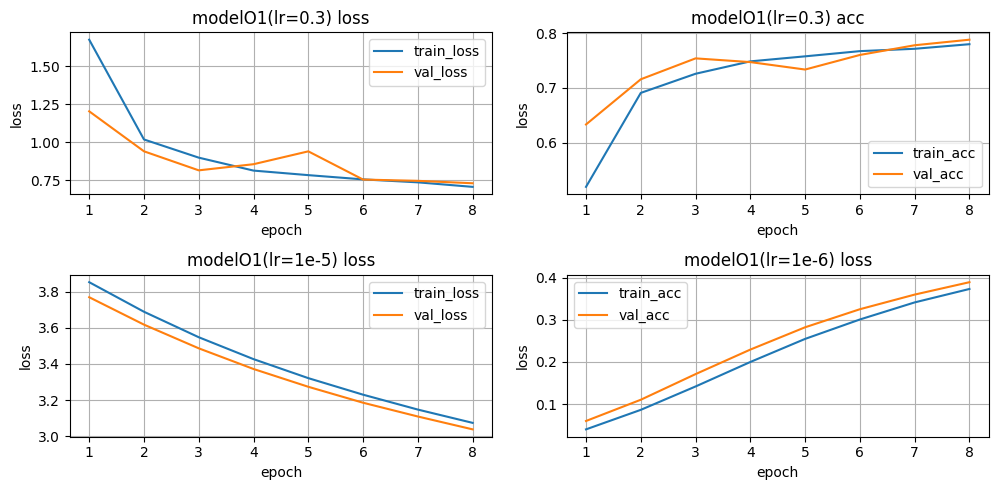

In [18]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))

ax[0, 0].plot(np.arange(1, 9), history_O1["train_loss"], label="train_loss")
ax[0, 0].plot(np.arange(1, 9), history_O1["val_loss"], label="val_loss")
ax[0, 0].set_xlabel("epoch")
ax[0, 0].set_ylabel("loss")
ax[0, 0].set_title("modelO1(lr=0.3) loss")
ax[0, 0].legend()
ax[0, 0].grid(True)
ax[0, 1].plot(np.arange(1, 9), history_O1["train_acc"], label="train_acc")
ax[0, 1].plot(np.arange(1, 9), history_O1["val_acc"], label="val_acc")
ax[0, 1].set_xlabel("epoch")
ax[0, 1].set_ylabel("loss")
ax[0, 1].set_title("modelO1(lr=0.3) acc")
ax[0, 1].legend()
ax[0, 1].grid(True)
ax[1, 0].plot(np.arange(1, 9), history_O2["train_loss"], label="train_loss")
ax[1, 0].plot(np.arange(1, 9), history_O2["val_loss"], label="val_loss")
ax[1, 0].set_xlabel("epoch")
ax[1, 0].set_ylabel("loss")
ax[1, 0].set_title("modelO1(lr=1e-5) loss")
ax[1, 0].legend()
ax[1, 0].grid(True)
ax[1, 1].plot(np.arange(1, 9), history_O2["train_acc"], label="train_acc")
ax[1, 1].plot(np.arange(1, 9), history_O2["val_acc"], label="val_acc")
ax[1, 1].set_xlabel("epoch")
ax[1, 1].set_ylabel("loss")
ax[1, 1].set_title("modelO1(lr=1e-6) loss")
ax[1, 1].legend()
ax[1, 1].grid(True)

plt.tight_layout()
fig.show()


d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01/15 | train loss=2.2405, acc=0.5318 | val loss=1.4066, acc=0.6916
epoch 02/15 | train loss=1.1194, acc=0.7308 | val loss=0.9062, acc=0.7655
epoch 03/15 | train loss=0.8021, acc=0.7835 | val loss=0.7262, acc=0.7971
epoch 04/15 | train loss=0.6553, acc=0.8125 | val loss=0.6368, acc=0.8118
epoch 05/15 | train loss=0.5692, acc=0.8318 | val loss=0.5799, acc=0.8231
epoch 06/15 | train loss=0.5102, acc=0.8451 | val loss=0.5489, acc=0.8301
epoch 07/15 | train loss=0.4649, acc=0.8557 | val loss=0.5243, acc=0.8354
epoch 08/15 | train loss=0.4283, acc=0.8661 | val loss=0.5093, acc=0.8387
epoch 09/15 | train loss=0.3994, acc=0.8729 | val loss=0.4957, acc=0.8410
epoch 10/15 | train loss=0.3749, acc=0.8789 | val loss=0.4873, acc=0.8419
epoch 11/15 | train loss=0.3519, acc=0.8866 | val loss=0.4790, acc=0.8425
epoch 12/15 | train loss=0.3305, acc=0.8921 | val loss=0.4757, acc=0.8453
epoch 13/15 | train loss=0.3139, acc=0.8963 | val loss=0.4726, acc=0.8460
epoch 14/15 | train loss=0.2961, acc=0

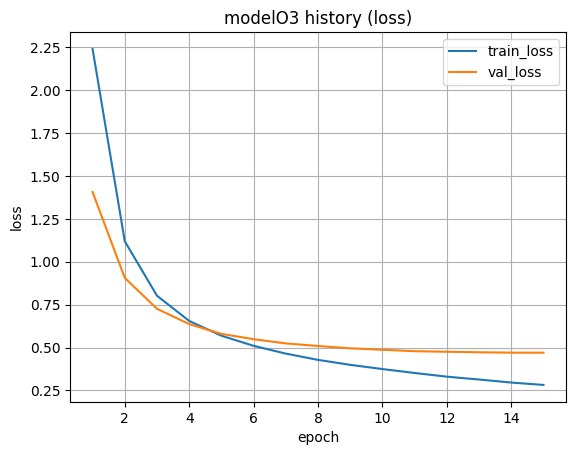

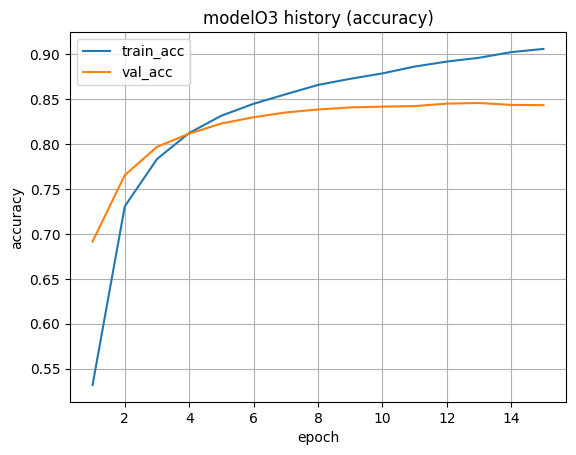

In [19]:
modelO3 = MLP(use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(modelO3.parameters(), momentum=0.9, weight_decay=1e-4, lr=1e-3)

history_O3 = fit(modelO3, train_loader, val_loader, optimizer, criterion, device, epochs=15)
plot_history(history_O3, "modelO3 history")

In [20]:
new_row = {
    "experiment_id": "O3",
    "dataset": "EMNIST",
    "seed": 42,
    "model_summary": {"hiden size": (512, 256, 128), 
                      "activation": "ReLU", 
                      "dropout": 0.0, 
                      "batchnorm": True},
    "optimizer": "SGD",
    "lr": 1e-3,
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "epochs_trained": 15,
    "best_val_accuracy": max(history_O3["val_acc"]),
    "best_val_loss": min(history_O3["val_loss"])
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)